In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch
import sys
from functools import partial
import time
sys.path.append("..")
from src.models import NeuralPosteriorEstimator, MarginalDensityFlow
from src.data.reinfection import BaseReinfectionModel
from src.models.embedding import TransformerEmbedding
from src.criticism import c2st
mps_device = torch.device("mps")

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

# Base SEIR Model

In [3]:
# priors
beta_prior = torch.distributions.Exponential(rate=0.2)
epsilon_prior = torch.distributions.Exponential(rate=2)
nu_prior = torch.distributions.Exponential(rate=2)
rho_prior = torch.distributions.Uniform(low=0.5, high=.99)

## Parameter Estimation

In [4]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True, load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
train_data, val_data = random_split(base_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=2000)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...
Time to simulate 200 samples: 2.8s.


In [25]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(4, 59, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 43.9 K | train
-------------------------------------------
43.9 K    Trainable params
0         Non-trainable params
43.9 K    Total params
0.176     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [26]:
x_o = base_dataset.get_observed_data()
posterior_sample = model.sample(100, x_o)
posterior_sample = base_dataset.transform_prior(posterior_sample, True)

In [27]:
prior_sample = base_dataset.transform_prior(base_dataset.theta, True)[:100]

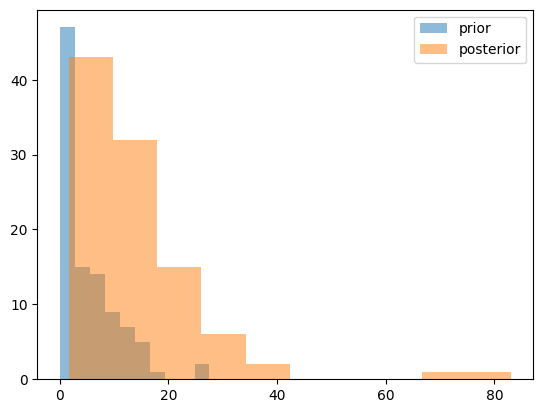

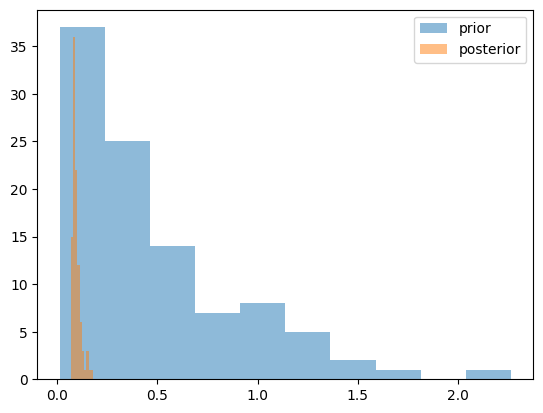

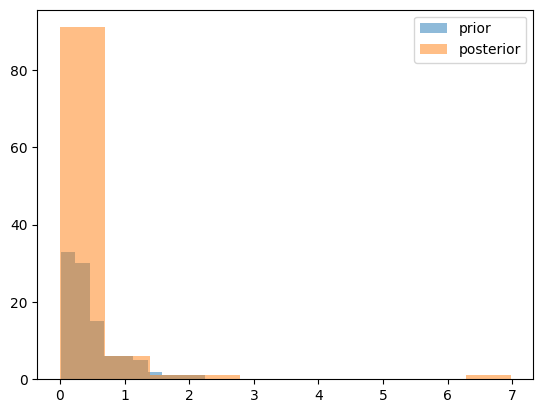

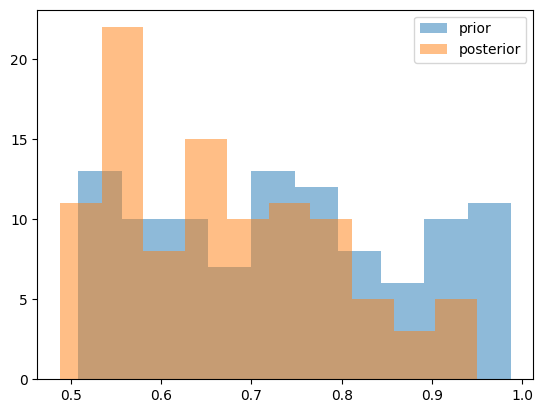

In [28]:
for i in range(4):
    plt.hist(prior_sample.T[i], alpha=0.5, label="prior")
    plt.hist(posterior_sample.T[i], alpha=0.5, label="posterior")
    plt.legend()
    plt.show()

In [30]:
parameters = ("beta", "epsilon", "nu", "rho")
for i, p in enumerate(parameters):
    print(f"Estimate of {p}: {posterior_sample.T[i].mean():.2f}")

Estimate of beta: 13.89
Estimate of epsilon: 0.10
Estimate of nu: 0.34
Estimate of rho: 0.67


# Predictive Checks

## Prior Predictive Checks

In [33]:
J = 100
prior_predictive = np.empty((J, 59))
for j in range(100):
    z = base_dataset.sample_prior(1, j)[0]
    x = base_dataset.simulate(z)
    prior_predictive[j] = x

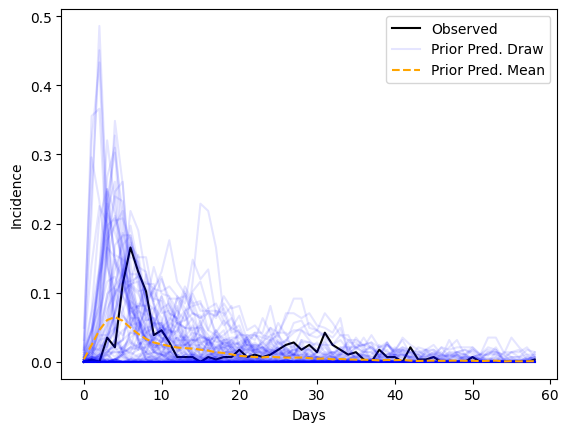

In [43]:
pp_mean = prior_predictive.mean(0)
labels = ["Prior Pred. Draw"] + [None for _ in range(J-1)]
plt.plot(x_o, label="Observed", color="k")
plt.plot(prior_predictive.T, label=labels, color="b", alpha=0.1)
plt.plot(pp_mean, label="Prior Pred. Mean", linestyle="--", color="orange")
plt.xlabel("Days")
plt.ylabel("Incidence")
plt.legend()
plt.show()

## Posterior Predictive Checks

In [42]:
J = 100
posterior_predictive = np.empty((J, 59))
for j in range(100):
    z = posterior_sample[j]
    x = base_dataset.simulate(z)
    posterior_predictive[j] = x

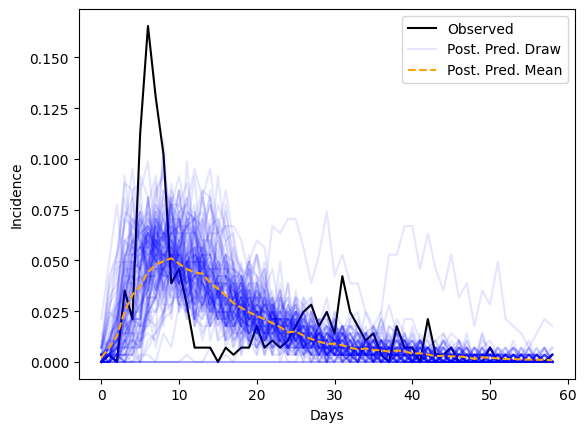

In [44]:
pp_mean = posterior_predictive.mean(0)
labels = ["Post. Pred. Draw"] + [None for _ in range(J-1)]
plt.plot(x_o, label="Observed", color="k")
plt.plot(posterior_predictive.T, label=labels, color="b", alpha=0.1)
plt.plot(pp_mean, label="Post. Pred. Mean", linestyle="--", color="orange")
plt.xlabel("Days")
plt.ylabel("Incidence")
plt.legend()
plt.show()

### Transformer Embeddings

In [6]:
# optim = partial(torch.optim.AdamW, lr=0.001)
# embedding = partial(TransformerEmbedding, d_model=8)
# model = NeuralPosteriorEstimator(4, torch.Size([1, 59]), 5, flow_type="MAF", optimizer=optim, embedding=embedding)
# callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
# trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
# trainer.fit(model, train_loader, val_loader)

In [47]:
# x_o = base_dataset.get_observed_data()
# posterior_sample = model.sample(100, x_o)
# posterior_sample = base_dataset.transform_prior(posterior_sample, True)

## Marginal Density Estimation

In [6]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True,
                                   mode="criticism", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
train_data, val_data = random_split(base_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=2000)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...
Time to simulate 200 samples: 2.8s.


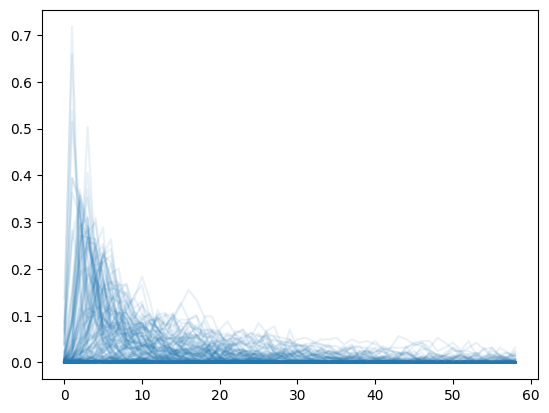

In [10]:
x_sample = base_dataset.data[:200].squeeze(1).T
plt.plot(x_sample, alpha=0.1, color="tab:blue")
plt.show()

#### First Pass: Brute Force
Can Normalizing Flows handle a length 59 time series?

In [15]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(59, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 78.4 K | train
--------------------------------------
78.4 K    Trainable params
0         Non-trainable params
78.4 K    Total params
0.313     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [18]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(1., dtype=torch.float64)

Yeah the performance is hilariously bad

#### Second Pass: Resampling

Surely we don't lose too much information if we reduce the length of the time series? It's applying summary statistics in a way. In fact, the same summary statistic applied to each simulator.

Code up: a helper function that does some sliding window summation

In [4]:
base_dataset = BaseReinfectionModel(init_I=1, init_S=277, n_sample=N, beta=beta_prior, 
                                    epsilon=epsilon_prior, nu=nu_prior, rho=rho_prior, notebook=True,
                                   mode="criticism", load_data=False)
start = time.time()
base_dataset.sample_model()
stop = time.time()
print(f"Time to simulate {N:,} samples: {stop - start:.1f}s.")
base_dataset.resample(6)

Simulating samples...


UnboundLocalError: cannot access local variable 'data' where it is not associated with a value

In [5]:

train_data, val_data = random_split(base_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

In [6]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = MarginalDensityFlow(10, 5, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name | Type | Params | Mode 
--------------------------------------
0 | flow | MAF  | 30.8 K | train
--------------------------------------
30.8 K    Trainable params
0         Non-trainable params
30.8 K    Total params
0.123     Total estimated model params size (MB)
39        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                  | 0/? [00:00<?, ?it/s]

Training: |                                                         | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

...

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

Validation: |                                                       | 0/? [00:00<?, ?it/s]

In [7]:
x_val, mll_val = trainer.predict(model, val_loader)[0]
samples = model.sample(x_val.shape[0])
c2st(x_val.squeeze(1), samples)

Predicting: |                                                       | 0/? [00:00<?, ?it/s]

tensor(0.9750, dtype=torch.float64)

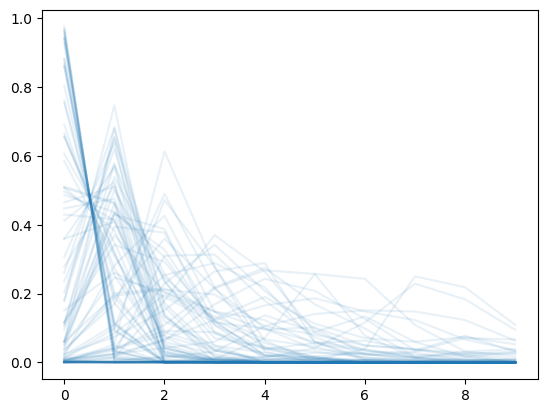

In [8]:
data_sample = base_dataset.data[:100].squeeze(1).T
plt.plot(data_sample, alpha=0.1, color="tab:blue")
plt.show()

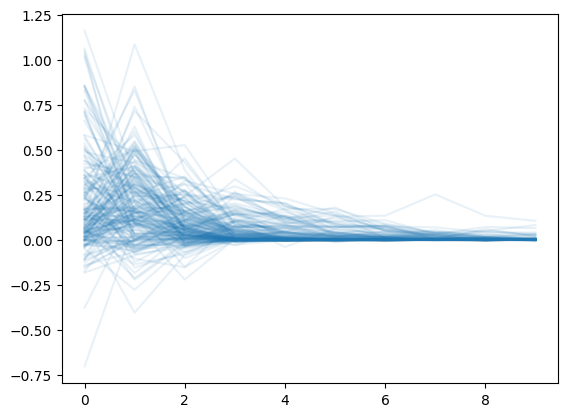

In [9]:
simulated_sample = samples[:200].T
plt.plot(simulated_sample, alpha=0.1, color="tab:blue")
plt.show()

In [ ]:
# x_sample = ch_dataset.data[:200].squeeze(1).T
# plt.plot(x_sample, alpha=0.1, color="tab:blue")
# plt.ylim(-0.1, 1.1)
# plt.show()

#### Third Pass: Learned Embeddings

The idea here is to apply an embedding network to the simulated data before running NPE. If we train NPE and the embedding network jointly, then the hope is that this embedding network learns an informative low-dimensional representation (e.g. summary statistic) of the data. My issue with this: it'd be different summary statistics for each model.